# AI Study Assistant

In [3]:
import os
import json
import re
from PIL import Image
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# Prevent OpenMP library collisions on Windows
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

load_dotenv(os.path.join("..", ".env"))

api_key = os.getenv("GROQ_API_KEY", "")
if api_key:
    print("GROQ_API_KEY found in .env")
else:
    print("GROQ_API_KEY is not set in .env")

GROQ_API_KEY found in .env


Loaded text file: data\sample\sample_text.txt (1896 characters)
Loaded image: (1380, 1428) PNG


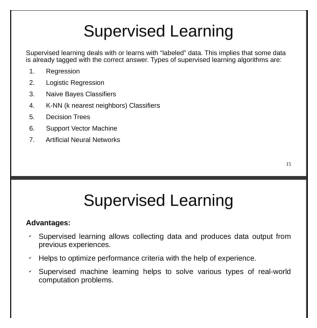

In [7]:
# Load Sample Text & Image
txt_path = os.path.join("data", "sample", "sample_text.txt")
with open(txt_path, "r", encoding="utf-8") as f:
    sample_study_text = f.read()

print(f"Loaded text file: {txt_path} ({len(sample_study_text)} characters)")

image_path = os.path.join("data", "sample", "sample_img.png")
image = Image.open(image_path)
print(f"Loaded image: {image.size} {image.format}")

plt.figure(figsize=(8, 4))
plt.imshow(image)
plt.axis("off")
plt.show()

In [8]:
# EasyOCR
import easyocr

def extract_text_with_easyocr(img_path):
    reader = easyocr.Reader(['en'], gpu=False, verbose=False)
    results = reader.readtext(str(img_path))
    lines = [res[1] for res in results]
    return "\n".join(lines)

print("Running EasyOCR on sample image...")
extracted_ocr_text = extract_text_with_easyocr(image_path)

print("\nExtracted OCR Text")
print(extracted_ocr_text)

Running EasyOCR on sample image...

Extracted OCR Text
Supervised Learning
Supervised learning deals with or learns with "labeled" data. This implies that some data
is already tagged with the correct answer: Types of supervised learning algorithms are:
13
Regression
2
Logistic Regression
3_
Naive Bayes Classifiers
4_
K-NN (k nearest neighbors) Classifiers
5_
Decision Trees
6_
Support Vector Machine
7
Artificial Neural Networks
15
Supervised Learning
Advantages:
Supervised learning allows collecting data and produces data output from
previous experiences:
Helps to optimize performance criteria with the help of experience.
Supervised
machine
learning helps
to
solve
various types
of real-world
computation problems:


In [9]:
# Part C: Text Cleaning
def clean_study_text(raw_text):
    lines = [line.strip() for line in raw_text.splitlines() if line.strip()]
    return "\n".join(lines)

cleaned_ocr_text = clean_study_text(extracted_ocr_text)
print("Cleaned OCR Text:")
print(cleaned_ocr_text)

Cleaned OCR Text:
Supervised Learning
Supervised learning deals with or learns with "labeled" data. This implies that some data
is already tagged with the correct answer: Types of supervised learning algorithms are:
13
Regression
2
Logistic Regression
3_
Naive Bayes Classifiers
4_
K-NN (k nearest neighbors) Classifiers
5_
Decision Trees
6_
Support Vector Machine
7
Artificial Neural Networks
15
Supervised Learning
Advantages:
Supervised learning allows collecting data and produces data output from
previous experiences:
Helps to optimize performance criteria with the help of experience.
Supervised
machine
learning helps
to
solve
various types
of real-world
computation problems:


In [10]:
# Strip <think> tags
def strip_thinking(text):
    return re.sub(r"<think>[\s\S]*?</think>", "", text).strip()

In [11]:
# Summarization
from groq import Groq

def generate_summary(text, user_api_key=None, model="openai/gpt-oss-120b"):
    key = user_api_key or os.getenv("GROQ_API_KEY")
    if not key:
        raise ValueError("Please provide a valid GROQ_API_KEY")
        
    client = Groq(api_key=key)
    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "system",
                "content": (
                    "You are an expert AI study assistant. "
                    "Summarize the key concepts of the provided study material in clear bullet points. "
                    "Make it concise and easy for a student to revise."
                )
            },
            {
                "role": "user",
                "content": f"Study Material:\n{text}\n\nPlease provide a summary:"
            }
        ],
        temperature=0.3,
        max_tokens=1024,
    )
    
    raw = response.choices[0].message.content
    return strip_thinking(raw)

print("Testing Summarization on sample text...")
summary_output = generate_summary(sample_study_text)
print("\nSUMMARY RESULT:\n")
print(summary_output)

Testing Summarization on sample text...

SUMMARY RESULT:

**Photosynthesis – Key Concepts**

- **What it is**  
  - Conversion of light energy into chemical energy (glucose).  
  - Performed by green plants, algae, and some bacteria.  
  - Produces O₂ and removes CO₂ → essential for life & climate regulation.

- **Where it happens**  
  - Leaves → chloroplasts.  
  - Chlorophyll (green pigment) absorbs red & blue light, reflects green.

- **Overall equation**  
  \[
  6\text{CO}_2 + 6\text{H}_2\text{O} + \text{light} \rightarrow \text{C}_6\text{H}_{12}\text{O}_6 + 6\text{O}_2
  \]

- **Two main stages**

  1. **Light‑Dependent Reactions** (thylakoid membranes)  
     - Light → excites chlorophyll → water split (photolysis).  
     - Products: O₂ (released), ATP, NADPH (energy carriers).

  2. **Light‑Independent Reactions (Calvin Cycle)** (stroma)  
     - Uses ATP + NADPH to fix CO₂ into glucose.  
     - Enzyme‑driven cycle discovered by Melvin Calvin.

- **Factors influencing rate**

In [28]:
# Question Answering
def ask_study_question(text, question, user_api_key=None, model="openai/gpt-oss-120b"):
    key = user_api_key or os.getenv("GROQ_API_KEY")
    if not key:
        raise ValueError("Please provide a valid GROQ_API_KEY")
        
    client = Groq(api_key=key)
    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "system",
                "content": (
                    "You are a helpful study tutor. "
                    "Answer the student's question using ONLY information from the study material provided. "
                    "Explain clearly and concisely."
                )
            },
            {
                "role": "user",
                "content": f"Study Material:\n{text}\n\nStudent Question: {question}"
            }
        ],
        temperature=0.3,
        max_tokens=1024,
    )
    
    raw = response.choices[0].message.content
    return strip_thinking(raw)

test_q = "What are the two main stages of photosynthesis and where do they occur?"
print(f"Question: {test_q}\n")
answer_output = ask_study_question(sample_study_text, test_q)
print("ANSWER:\n")
print(answer_output)

Question: What are the two main stages of photosynthesis and where do they occur?

ANSWER:

The two main stages of photosynthesis are:

1. **Light‑Dependent Reactions** – These take place in the **thylakoid membranes** of the chloroplasts.  
2. **Light‑Independent Reactions (Calvin Cycle)** – These occur in the **stroma** of the chloroplasts.


In [30]:
# MCQ Quiz Generation
def generate_study_quiz(text, num_questions=3, user_api_key=None, model="openai/gpt-oss-120b"):
    key = user_api_key or os.getenv("GROQ_API_KEY")
    if not key:
        raise ValueError("Please provide a valid GROQ_API_KEY")
        
    client = Groq(api_key=key)
    system_prompt = (
        "You are a quiz generator. Generate multiple-choice questions based on the study text.\n"
        "Return ONLY a valid JSON array of objects. Do not include markdown or explanations outside the JSON.\n"
        "JSON Structure:\n"
        "[\n"
        "  {\n"
        '    "question": "What is ...?",\n'
        '    "options": ["A) Option 1", "B) Option 2", "C) Option 3", "D) Option 4"],\n'
        '    "answer": "A) Option 1"\n'
        "  }\n"
        "]"
    )
    
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": f"Generate {num_questions} MCQs from this text:\n\n{text}"}
        ],
        temperature=0.2,
        max_tokens=2048,
    )
    
    raw = response.choices[0].message.content.strip()
    
    # 1. Strip reasoning think tags if present
    raw = strip_thinking(raw)
    
    # 2. Extract JSON from markdown fences if present
    if "```" in raw:
        match = re.search(r"```(?:json)?\s*([\s\S]*?)\s*```", raw)
        if match:
            raw = match.group(1).strip()
            
    # 3. Find JSON array boundaries
    start_idx = raw.find('[')
    end_idx = raw.rfind(']')
    if start_idx != -1 and end_idx != -1:
        raw = raw[start_idx:end_idx + 1]
        
    return json.loads(raw)

print(f"Generating 3 MCQs from sample text...")
quiz_data = generate_study_quiz(sample_study_text, num_questions=3)
print("\nGENERATED QUIZ:\n")
for i, item in enumerate(quiz_data, 1):
    print(f"Q{i}: {item['question']}")
    for opt in item['options']:
        print(f"   {opt}")
    print(f"Correct Answer: {item['answer']}\n")

Generating 3 MCQs from sample text...

GENERATED QUIZ:

Q1: According to the overall photosynthesis equation, which of the following correctly represents the reactants and products?
   A) 6CO2 + 6H2O + light energy → C6H12O6 + 6O2
   B) 6O2 + 6H2O + light energy → C6H12O6 + 6CO2
   C) C6H12O6 + 6O2 → 6CO2 + 6H2O + light energy
   D) 6CO2 + C6H12O6 → 6H2O + 6O2
Correct Answer: A) 6CO2 + 6H2O + light energy → C6H12O6 + 6O2

Q2: In which part of the chloroplast do the light‑dependent reactions take place?
   A) Stroma
   B) Thylakoid membranes
   C) Cytoplasm
   D) Mitochondrial matrix
Correct Answer: B) Thylakoid membranes

Q3: Which of the following is NOT listed as a factor that affects the rate of photosynthesis?
   A) Light intensity
   B) Carbon dioxide concentration
   C) Soil pH
   D) Temperature
Correct Answer: C) Soil pH

